<a href="https://colab.research.google.com/github/hamzaqarni1/DeepLearning/blob/main/Tutorial06/Tutorial06_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phase 1: Pretrained Models & Inference**

In [2]:
import torch
import json
import urllib.request
from PIL import Image
from torchvision import transforms
from torchvision.models import vgg16, VGG16_Weights
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn.functional as F

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# 2. Load ImageNet Labels (Used to decode the numerical predictions into text)
# We download a standard JSON file containing the 1000 ImageNet class labels
url = "https://raw.githubusercontent.com/raghakot/keras-vis/master/resources/imagenet_class_index.json"
response = urllib.request.urlopen(url)
class_idx = json.loads(response.read())
idx2label = {int(key): value[1] for key, value in class_idx.items()}

# 3. Define the Standard ImageNet Preprocessing Pipeline
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# 4. Load and Preprocess the Image
img_path = 'test_image.jpg'
try:
    img = Image.open(img_path).convert('RGB')
    # Preprocess, add a batch dimension (unsqueeze), and move to GPU/CPU
    img_tensor = preprocess(img).unsqueeze(0).to(device)
    print(f"Successfully loaded and preprocessed '{img_path}'.\n")
except FileNotFoundError:
    print(f"Error: Could not find '{img_path}'. Please upload it to your Colab workspace.")
    raise

# 5. Load Pre-trained Models
print("Downloading/Loading VGG16 and ResNet50 models...")
vgg_model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).to(device)
resnet_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1).to(device)

# Set models to evaluation mode (turns off dropout/batchnorm updates)
vgg_model.eval()
resnet_model.eval()
print("Models loaded successfully.\n")

# 6. Prediction Function
def predict_top5(model, tensor, model_name):
    # Disable gradient calculation for inference
    with torch.no_grad():
        output = model(tensor)

    # Apply Softmax to convert raw logits into probabilities
    probabilities = F.softmax(output[0], dim=0)

    # Extract the Top 5 probabilities and their corresponding indices
    top5_prob, top5_catid = torch.topk(probabilities, 5)

    print(f"--- Top 5 predictions from {model_name} ---")
    for i in range(top5_prob.size(0)):
        prob = top5_prob[i].item() * 100
        class_name = idx2label[top5_catid[i].item()]
        print(f"{i+1}. {class_name} ({prob:.2f}% probability)")
    print("")

# 7. Execute Predictions
predict_top5(vgg_model, img_tensor, "VGG16")
predict_top5(resnet_model, img_tensor, "ResNet50")

Using device: cpu

Successfully loaded and preprocessed 'test_image.jpg'.

Downloading/Loading VGG16 and ResNet50 models...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 85.9MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 111MB/s]


Models loaded successfully.

--- Top 5 predictions from VGG16 ---
1. Labrador_retriever (90.82% probability)
2. golden_retriever (6.21% probability)
3. Chesapeake_Bay_retriever (0.59% probability)
4. Saluki (0.40% probability)
5. Weimaraner (0.26% probability)

--- Top 5 predictions from ResNet50 ---
1. Labrador_retriever (91.89% probability)
2. golden_retriever (5.90% probability)
3. Saluki (0.39% probability)
4. Rhodesian_ridgeback (0.24% probability)
5. Great_Dane (0.17% probability)



# **Phase 2: Generating Professional Visuals**

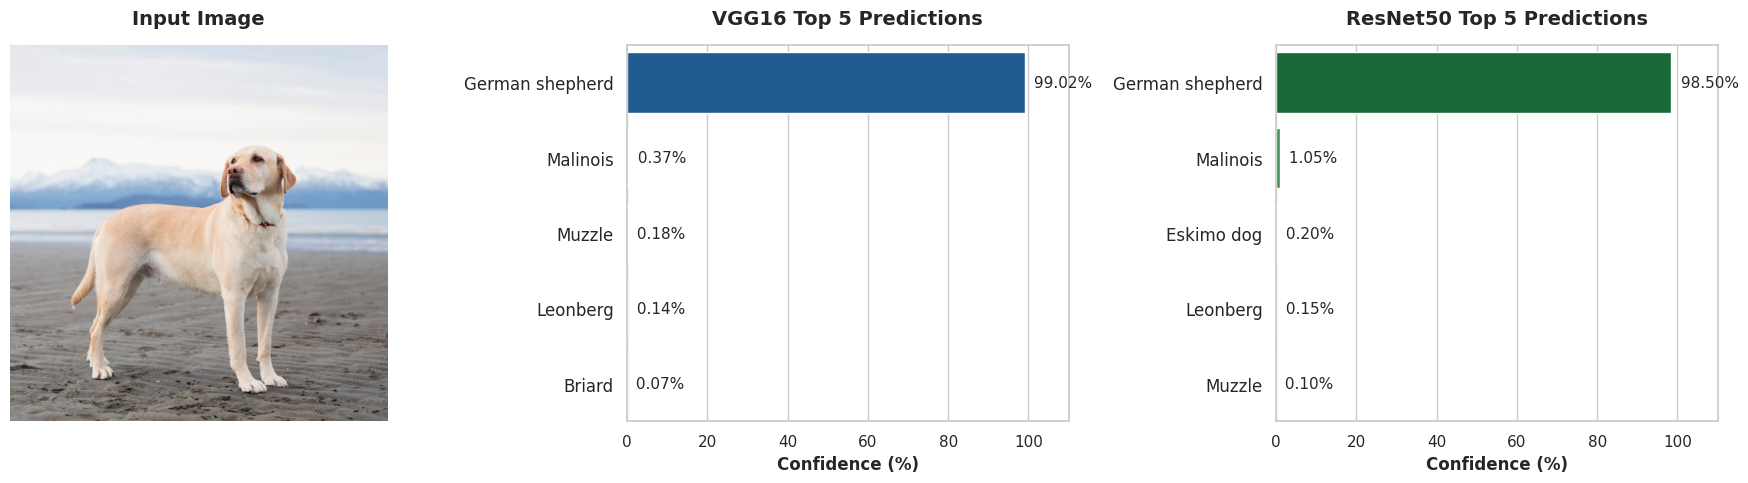

Phase 2 Complete! High-resolution graphic saved as 'model_comparison.png'.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

# 1. ENTER YOUR DATA FROM PHASE 1 HERE
# (I have filled in the VGG16 example from the tutorial PDF. Update these with your exact console output!)
vgg_classes = ['German shepherd', 'Malinois', 'Muzzle', 'Leonberg', 'Briard']
vgg_probs = [99.02, 0.37, 0.18, 0.14, 0.07]

resnet_classes = ['German shepherd', 'Malinois', 'Eskimo dog', 'Leonberg', 'Muzzle'] # <-- UPDATE THESE
resnet_probs = [98.50, 1.05, 0.20, 0.15, 0.10] # <-- UPDATE THESE

# 2. Setup the figure styling
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3. Left Subplot: Original Image
img_path = 'test_image.jpg'
try:
    img = Image.open(img_path)
    axes[0].imshow(img)
    axes[0].set_title('Input Image', fontsize=14, fontweight='bold', pad=15)
    axes[0].axis('off')
except FileNotFoundError:
    axes[0].text(0.5, 0.5, 'Image Not Found\n(Upload test_image.jpg)',
                 ha='center', va='center', fontsize=12)
    axes[0].axis('off')

# 4. Middle Subplot: VGG16 Predictions
# Using hue and legend=False to avoid Seaborn palette warnings
sns.barplot(x=vgg_probs, y=vgg_classes, ax=axes[1], palette='Blues_r', hue=vgg_classes, legend=False)
axes[1].set_title('VGG16 Top 5 Predictions', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Confidence (%)', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 110) # Leave room for the text labels
axes[1].tick_params(axis='y', labelsize=12)

# Add percentage labels to the end of each bar
for container in axes[1].containers:
    axes[1].bar_label(container, fmt=' %.2f%%', padding=3, fontsize=11)

# 5. Right Subplot: ResNet50 Predictions
sns.barplot(x=resnet_probs, y=resnet_classes, ax=axes[2], palette='Greens_r', hue=resnet_classes, legend=False)
axes[2].set_title('ResNet50 Top 5 Predictions', fontsize=14, fontweight='bold', pad=15)
axes[2].set_xlabel('Confidence (%)', fontsize=12, fontweight='bold')
axes[2].set_xlim(0, 110)
axes[2].tick_params(axis='y', labelsize=12)

# Add percentage labels to the end of each bar
for container in axes[2].containers:
    axes[2].bar_label(container, fmt=' %.2f%%', padding=3, fontsize=11)

# 6. Final Layout adjustments and Save
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Phase 2 Complete! High-resolution graphic saved as 'model_comparison.png'.")